## Library Import

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")


## Data import

In [20]:


df_games = pd.read_csv("../Tables/table_games.csv")
df_genres = pd.read_csv("../Tables/table_genrer.csv")
df_reviews = pd.read_csv("../Tables/table_review.csv")
df_game_genres = pd.read_csv("../Tables/subtable_genrerxappid.csv")


print(df_games.head())

     appid                              name         developer  \
0      730  Counter-Strike: Global Offensive             Valve   
1  1172470                      Apex Legends           Respawn   
2   578080               PUBG: BATTLEGROUNDS  PUBG Corporation   
3  1623730                          Palworld        Pocketpair   
4      440                   Team Fortress 2             Valve   

                       owners  price  initialprice  discount      ccu  
0  100,000,000 .. 200,000,000      0             0         0  1013936  
1  100,000,000 .. 200,000,000      0             0         0   124262  
2  100,000,000 .. 200,000,000      0             0         0   314682  
3   50,000,000 .. 100,000,000   2999          2999         0    18028  
4   50,000,000 .. 100,000,000      0             0         0    43819  


## Data inconsistency check

In [21]:


def df_summary(df):
    return pd.DataFrame({
        "Column": df.columns,
        "Non-Null": df.notnull().sum().values,
        "Dtype": df.dtypes.values,
        "Nulls": df.isnull().sum().values
    })



In [22]:
df_summary(df_games).style.background_gradient(cmap="Blues")



,Column,Non-Null,Dtype,Nulls
0,appid,1000,int64,0
1,name,1000,str,0
2,developer,1000,str,0
3,owners,1000,str,0
4,price,1000,int64,0
5,initialprice,1000,int64,0
6,discount,1000,int64,0
7,ccu,1000,int64,0


In [23]:
df_games.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   appid         1000 non-null   int64
 1   name          1000 non-null   str  
 2   developer     1000 non-null   str  
 3   owners        1000 non-null   str  
 4   price         1000 non-null   int64
 5   initialprice  1000 non-null   int64
 6   discount      1000 non-null   int64
 7   ccu           1000 non-null   int64
dtypes: int64(5), str(3)
memory usage: 62.6 KB


In [24]:
df_summary(df_reviews).style.background_gradient(cmap="Blues")


,Column,Non-Null,Dtype,Nulls
0,appid,1000,int64,0
1,median_forever,1000,int64,0
2,review_sentiment,1000,str,0
3,score,1000,int64,0


In [25]:
df_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   appid             1000 non-null   int64
 1   median_forever    1000 non-null   int64
 2   review_sentiment  1000 non-null   str  
 3   score             1000 non-null   int64
dtypes: int64(3), str(1)
memory usage: 31.4 KB


In [26]:
df_summary(df_genres).style.background_gradient(cmap="Blues")

,Column,Non-Null,Dtype,Nulls
0,genre_name,20,str,1
1,genre_id,21,int64,0


In [27]:
df_genres.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   genre_name  20 non-null     str  
 1   genre_id    21 non-null     int64
dtypes: int64(1), str(1)
memory usage: 468.0 bytes


## Descriptive Analysis

Undestanding the structure and general characteristics of the data

### Tables:

games: Contains game-related data such as price, concurrent users (CCU), and ownership range.

genres: Lists available game genres.

reviews: Includes review sentiment and scores.



In [28]:
dfs = {
    "games": df_games,
    "genres": df_genres,
    "reviews": df_reviews
}

for name, df in dfs.items():
    print(f"\n{name.upper()}")
    display(df.describe())


GAMES


,appid,price,initialprice,discount,ccu
count,1.000000e+03,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,6.284030e+05,1790.663000,2004.821000,7.826000,4.719540e+03
std,6.146411e+05,1752.742905,1797.224782,22.896899,3.526911e+04
min,1.000000e+01,0.000000,0.000000,0.000000,0.000000e+00
25%,2.281350e+05,162.500000,199.000000,0.000000,6.950000e+01
50%,4.100200e+05,1499.000000,1999.000000,0.000000,3.730000e+02
75%,8.950000e+05,2999.000000,2999.000000,0.000000,1.661500e+03
max,3.241660e+06,6999.000000,7999.000000,95.000000,1.013936e+06



GENRES


,genre_id
count,21.000000
mean,11.000000
std,6.204837
min,1.000000
25%,6.000000
50%,11.000000
75%,16.000000
max,21.000000



REVIEWS


,appid,median_forever,score
count,1.000000e+03,1000.000000,1000.000000
mean,6.284030e+05,704.781000,4.675000
std,6.146411e+05,1214.086984,0.599779
min,1.000000e+01,0.000000,1.000000
25%,2.281350e+05,174.750000,4.000000
50%,4.100200e+05,347.000000,5.000000
75%,8.950000e+05,765.250000,5.000000
max,3.241660e+06,12061.000000,5.000000


## Game Prices' distribution

In [29]:
df_games["is_free"] = df_games["price"] == 0

df_games["is_free_label"] = df_games["is_free"].map({
    True: "Free",
    False: "Paid"
})

C:\Users\Brandon\AppData\Local\Temp\ipykernel_8064\2018678868.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Brandon\AppData\Local\Temp\ipykernel_8064\2018678868.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


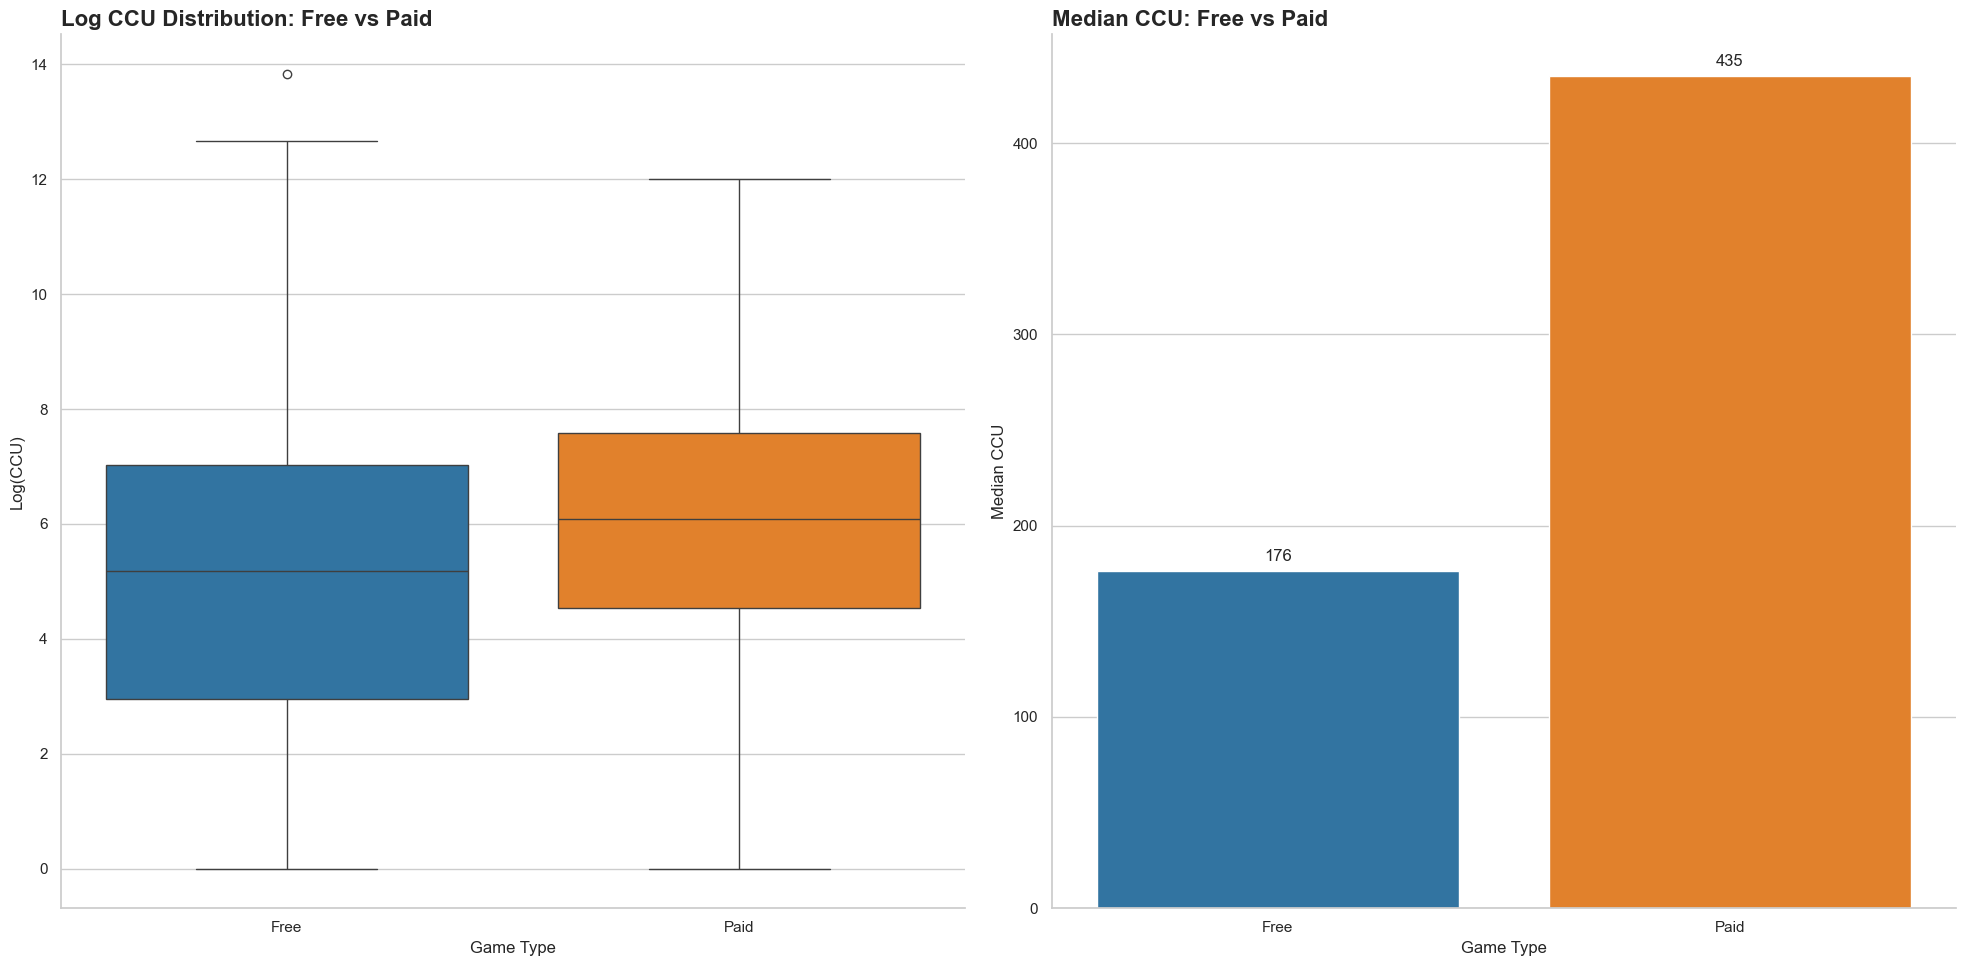

In [30]:

fig, ax = plt.subplots(1, 2, figsize=(20,10))

sns.set(style="white", font_scale=1.5)
sns.despine(left=False, bottom=False)

df_games["ccu_log"] = np.log1p(df_games["ccu"])

# Boxplot 
sns.boxplot(
    data=df_games,
    x="is_free_label",
    y="ccu_log",
    ax=ax[0],
    palette="tab10"
)

ax[0].set_title("Log CCU Distribution: Free vs Paid", loc='left', fontsize=16, fontweight='bold')
ax[0].set_xlabel("Game Type")
ax[0].set_ylabel("Log(CCU)")

# Average
sns.barplot(
    data=df_games,
    x="is_free_label",
    y="ccu",
    estimator=np.median,
    errorbar=None,
    ax=ax[1],
    palette="tab10"
)

ax[1].set_title("Median CCU: Free vs Paid", loc='left', fontsize=16, fontweight='bold')
ax[1].set_xlabel("Game Type")
ax[1].set_ylabel("Median CCU")


for p in ax[1].patches:
    ax[1].annotate(
        f'{p.get_height():.0f}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center', va='bottom',
        fontsize=12,
        xytext=(0,5),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()


The initial comparison using average CCU was heavily influenced by extreme outliers, leading to potentially misleading conclusions about the relative popularity of free and paid games.

A new visualization was created to reduce the impact of extreme outliers that distorted the average CCU. By applying a log transformation and using the median, this chart provides a more reliable view of typical game popularity.

C:\Users\Brandon\AppData\Local\Temp\ipykernel_8064\1696674846.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


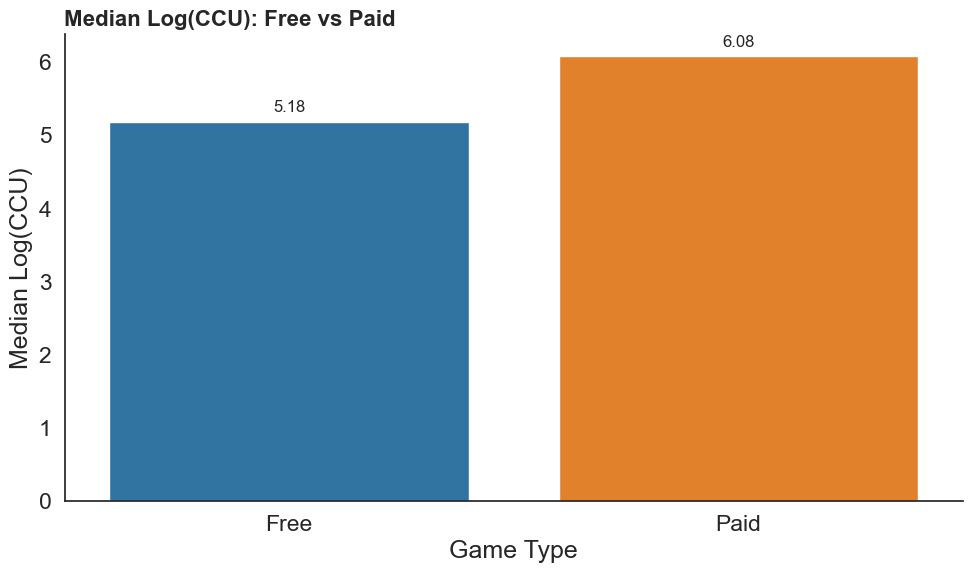

In [31]:



df_games["ccu_log"] = np.log1p(df_games["ccu"])


fig, ax = plt.subplots(figsize=(10,6))

sns.set(style="white", font_scale=1.3)
sns.despine(left=False, bottom=False)

sns.barplot(
    data=df_games,
    x="is_free_label",
    y="ccu_log",
    estimator=np.median,
    errorbar=None,
    palette="tab10",
    ax=ax
)

ax.set_title("Median Log(CCU): Free vs Paid", loc='left', fontsize=16, fontweight='bold')
ax.set_xlabel("Game Type")
ax.set_ylabel("Median Log(CCU)")


for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center', va='bottom',
        fontsize=12,
        xytext=(0,5),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

After applying a log transformation and using the median, the apparent difference in popularity between free and paid games becomes less pronounced. This suggests that extreme outliers drive most of the observed differences, rather than typical game performance.


## Gender distribution


In [32]:
# merge tables
df = df_game_genres.merge(df_genres, on="genre_id")
df.head()

,appid,genre_id,genre_name
0,730,1,Action
1,1172470,1,Action
2,1172470,2,Adventure
3,578080,1,Action
4,578080,2,Adventure


In [33]:
# count  and group games by gender

genre_counts = df.groupby("genre_name")["appid"].nunique().sort_values(ascending=False).reset_index()
genre_counts.columns = ["Genero", "Cantidad"]

df_counts = (
    df_game_genres
    .groupby("appid")["genre_id"]
    .nunique()
    .reset_index(name="num_genres")
)



In [34]:
df_plot = (
    df_counts
    .groupby("num_genres")
    .size()
    .reset_index(name="Count")
    .sort_values("num_genres")
)

<>:53: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:53: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
C:\Users\Brandon\AppData\Local\Temp\ipykernel_8064\3546427102.py:53: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  plt.savefig("D:\Proyectos\SteamCB\Media/gender_distribution.png", bbox_inches='tight', dpi=300)
C:\Users\Brandon\AppData\Local\Temp\ipykernel_8064\3546427102.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Brandon\AppData\Local\Temp\ipykernel_8064\3546427102.py:33: FutureWarning: 

Passing `palette` without

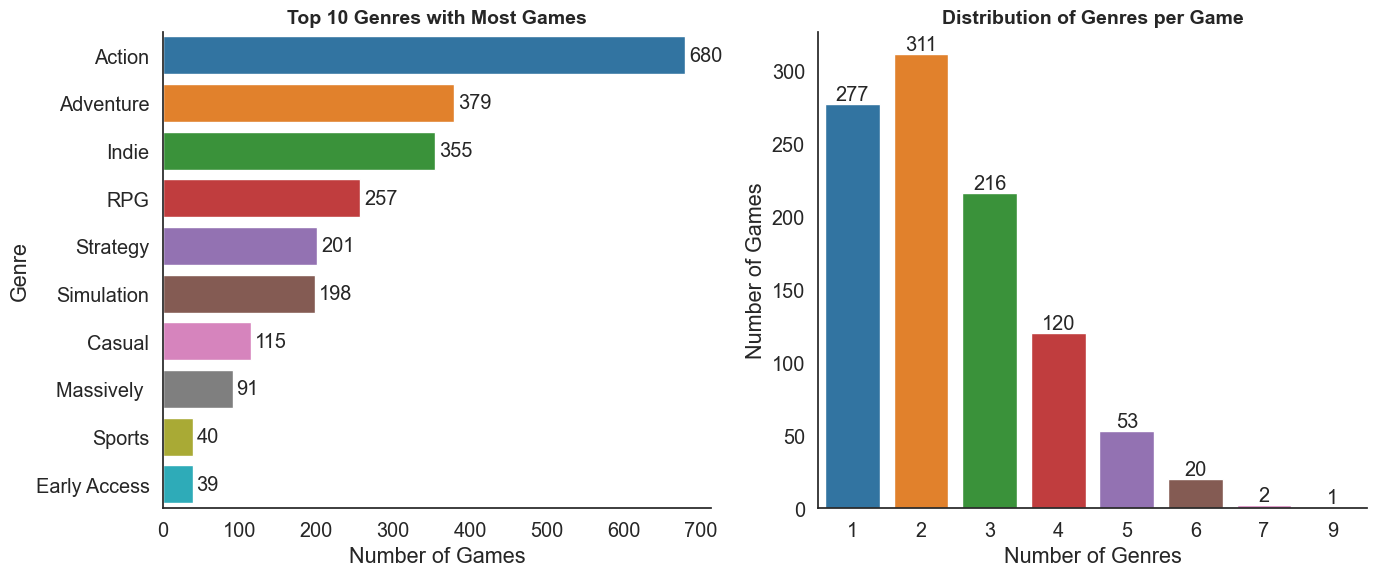

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(14,6))

sns.set(style="white", font_scale=1.2)
sns.despine(left=False, bottom=False)

# -------------------
# Plot 1: Top genres
# -------------------
df_top = genre_counts.head(10)

sns.barplot(
    data=df_top,
    y="Genero",
    x="Cantidad",
    palette="tab10",
    ax=ax[0]
)

ax[0].set_title("Top 10 Genres with Most Games", fontsize=14, fontweight='bold')
ax[0].set_xlabel("Number of Games")
ax[0].set_ylabel("Genre")

for p in ax[0].patches:
    ax[0].annotate(
        f'{int(p.get_width())}',
        (p.get_width() + 5, p.get_y() + p.get_height()/2),
        ha='left', va='center'
    )

# -------------------
# Plot 2: Distribution
# -------------------
sns.barplot(
    data=df_plot,
    x="num_genres",
    y="Count",
    palette="tab10",
    ax=ax[1]
)

ax[1].set_title("Distribution of Genres per Game", fontsize=14, fontweight='bold')
ax[1].set_xlabel("Number of Genres")
ax[1].set_ylabel("Number of Games")

for p in ax[1].patches:
    ax[1].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom'
    )

plt.tight_layout()
plt.savefig("D:\Proyectos\SteamCB\Media/gender_distribution.png", bbox_inches='tight', dpi=300)
plt.show()


## Reviews

In [36]:
df_reviews.head()

,appid,median_forever,review_sentiment,score
0,730,6472,positive,5
1,1172470,896,positive,4
2,578080,5624,positive,3
3,1623730,2308,positive,5
4,440,4826,positive,5


## Sentitive distribution

In [37]:
sentiment_counts = df_reviews["review_sentiment"].value_counts()

<>:22: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:22: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
C:\Users\Brandon\AppData\Local\Temp\ipykernel_8064\109800589.py:22: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  plt.savefig("D:\Proyectos\SteamCB\Media/sentiment_distribution.png", bbox_inches='tight', dpi=300)


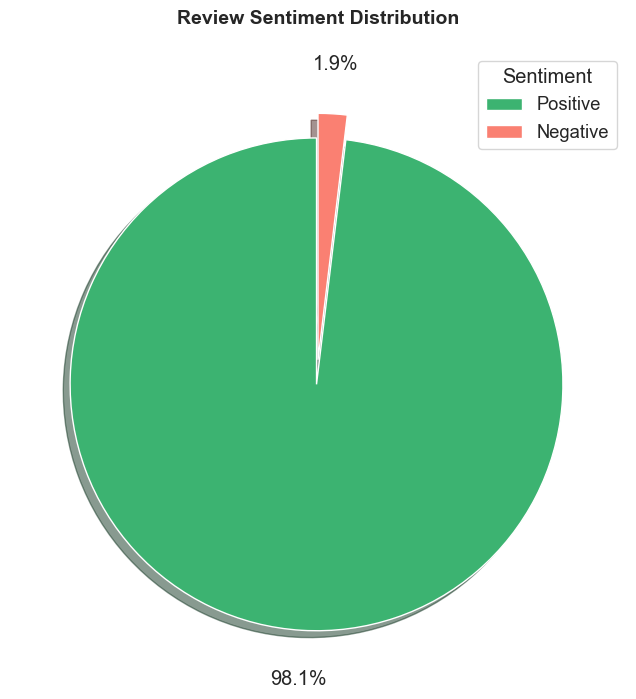

In [38]:
sentiment_counts.plot(
    kind='pie',
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    explode=(0.1, 0),
    colors=['mediumseagreen', 'salmon'],  # 👈 verde más suave
    pctdistance=1.2,
    figsize=(8, 8)
)

plt.title("Review Sentiment Distribution", fontsize=14, fontweight='bold', pad=20)
plt.ylabel('')

plt.legend(
    title='Sentiment',
    labels=["Positive", "Negative"],
    bbox_to_anchor=(1, 1)
)

plt.savefig("D:\Proyectos\SteamCB\Media/sentiment_distribution.png", bbox_inches='tight', dpi=300)
plt.show()


# Engancement


In [39]:
# Score organization

df_score = df_reviews["score"].value_counts().reset_index()
df_score.columns = ["Score", "Amount"]

In [40]:
# top median

df_top = df_merged.sort_values(by='median_forever', ascending=False).head(20)

NameError: name 'df_merged' is not defined

In [ ]:
# mean score
score_mean = df_top['score'].mean()
print(score_mean)

4.4


<>:45: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:45: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
C:\Users\Brandon\AppData\Local\Temp\ipykernel_21512\2822405113.py:45: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  plt.savefig("D:\Proyectos\SteamCB\Media/scores.png", bbox_inches='tight', dpi=300)
C:\Users\Brandon\AppData\Local\Temp\ipykernel_21512\2822405113.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


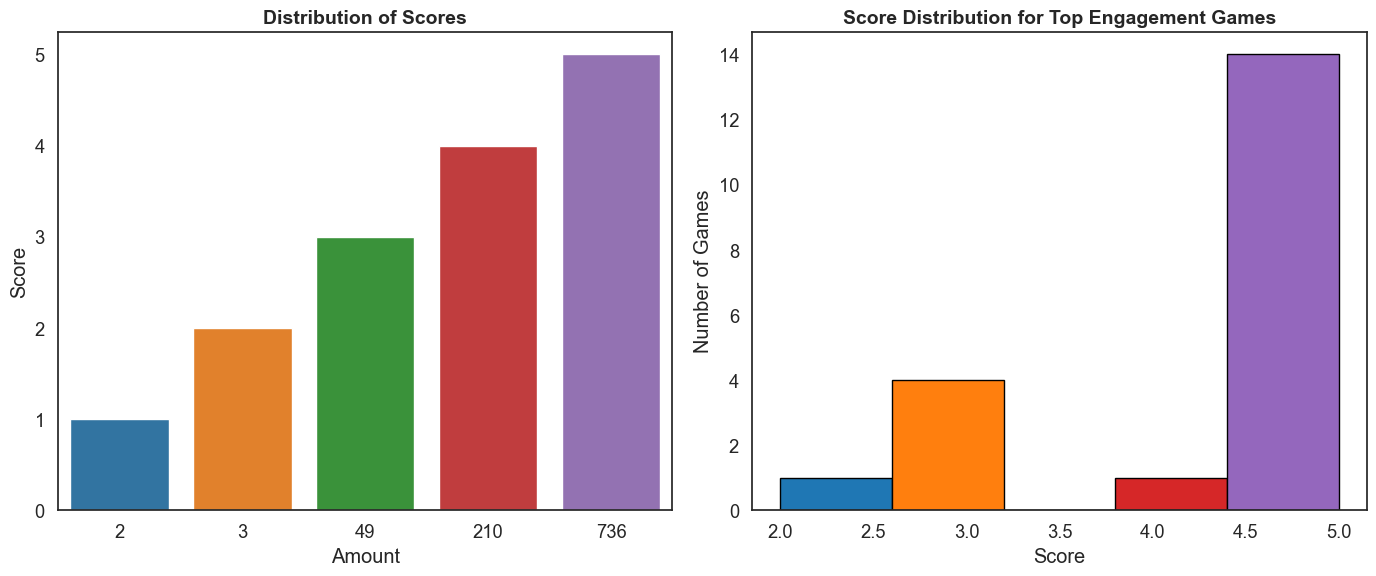

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14,6))

# --- BARPLOT ---
sns.barplot(
    data=df_score,
    y="Score",
    x="Amount",
    palette="tab10",
    ax=ax[0]
)

ax[0].set_title("Distribution of Scores", fontsize=14, fontweight='bold')
ax[0].set_xlabel("Amount")
ax[0].set_ylabel("Score")

# Add value labels to each bar
for p in ax[0].patches:
    ax[0].annotate(
        f'{int(p.get_width())}',
        (p.get_width() + 5, p.get_y() + p.get_height()/2),
        ha='left', va='center'
    )


# --- HISTOGRAM ---
sns.histplot(
    data=df_top,
    x='score',
    bins=5,
    edgecolor='black',
    ax=ax[1]
)

# Apply tab10 color palette to each bar
colors = sns.color_palette("tab10", len(ax[1].patches))

for patch, color in zip(ax[1].patches, colors):
    patch.set_facecolor(color)

ax[1].set_title("Score Distribution for Top Engagement Games", fontsize=14, fontweight='bold')
ax[1].set_xlabel("Score")
ax[1].set_ylabel("Number of Games")

plt.tight_layout()
plt.savefig("D:\Proyectos\SteamCB\Media/scores.png", bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# Merge games whit reviews to show name's tags
df_merged = df_reviews.merge(
    df_games[['appid', 'name']],
    on='appid',
    how='left'
)

list(df_merged.columns)

['appid', 'median_forever', 'review_sentiment', 'score', 'name']

In [ ]:
# top games more played

df_top = df_merged.groupby('name')['median_forever'] \
                  .mean() \
                  .sort_values(ascending=False) \
                  .head(10) \
                  .reset_index()

df_top.columns = ['Juego', 'Median']

C:\Users\Brandon\AppData\Local\Temp\ipykernel_21512\1563009183.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


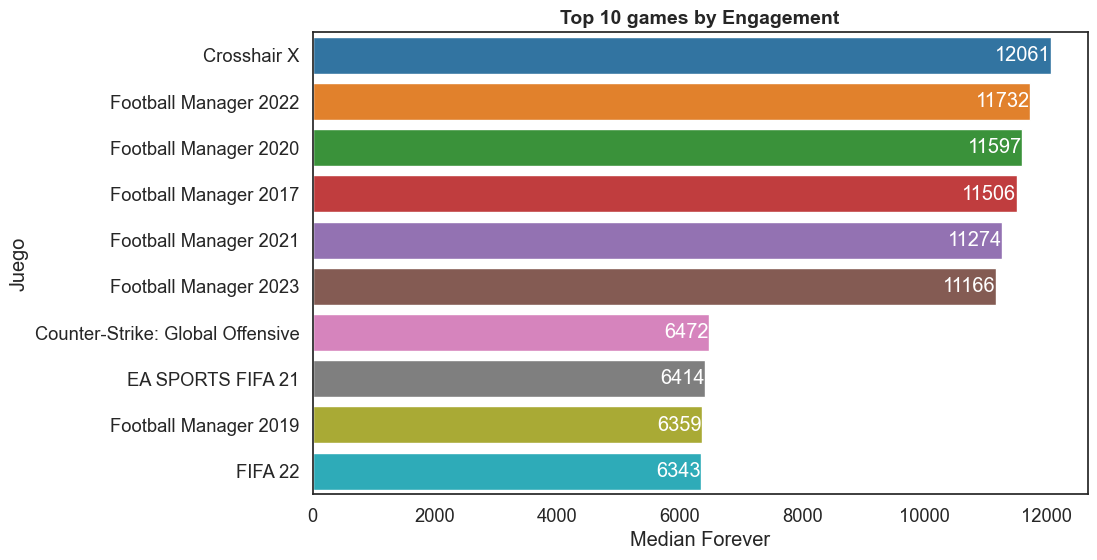

In [ ]:


fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(
    data=df_top,
    y="Juego",
    x="Median",
    palette="tab10",   # 👈 mismo estilo que tu ejemplo
    ax=ax
)

ax.set_title("Top 10 games by Engagement", fontsize=14, fontweight='bold')
ax.set_xlabel("Median Forever")
ax.set_ylabel("Juego")

# Anotations
for p in ax.patches:
    width = p.get_width()
    
    ax.annotate(
        f'{int(width)}',
        (width - 5 if width > 20 else width + 5,  # 👈 dentro o fuera según tamaño
         p.get_y() + p.get_height()/2),
        ha='right' if width > 20 else 'left',
        va='center',
        color='white' if width > 20 else 'black'
    )

plt.show()